# Mode Counting, Aliasing and Hydrometeor Weight Algorithms

## Import Python packages
First python packages are loaded.

## Import Packages and Download files

In [44]:
import os
import gzip
import shutil
import tempfile
import math
import glob
import datetime as dt
from datetime import timedelta
from phd_clouds.utils import download_cloudnet_products
from rpgpy import rpg2nc as rpg2nc_rpgpy
from pdb import set_trace

import xarray as xr
import numpy as np


from scipy import stats
from scipy.signal import correlate
from scipy.optimize import curve_fit
from scipy import signal
from scipy import ndimage
from scipy.ndimage import gaussian_filter1d


from tabulate import tabulate

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import matplotlib.pylab as pl

from netCDF4 import Dataset
# import radar_calibration as rc
from rpgpy import rpg2nc
import cloudnetpy as cnp



from typing import Optional, List, Tuple, Union


import time

# Download files

In [45]:
#Get filepaths
# filepath_20210522 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210522_granada_rpg-fmcw-94.nc'
# filepath_20210523 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210523_granada_rpg-fmcw-94.nc'
# filepath_20210605 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210605_granada_rpg-fmcw-94.nc'
# filepath_20210608 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210608_granada_rpg-fmcw-94.nc'
# filepath_20210612 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210612_granada_rpg-fmcw-94.nc'
# filepath_20210614 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210614_granada_rpg-fmcw-94.nc'
# filepath_20210615 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210615_granada_rpg-fmcw-94.nc'
# filepath_20210616 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210616_granada_rpg-fmcw-94.nc'
filepath_20210913 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210913_granada_rpg-fmcw-94.nc'
filepath_20210913_classification = r'/media/matheustolen/Seagate Basic/cloudnet/classification/20210913_granada_classification.nc'
# filepath_20210320 = r'/media/matheustolen/Seagate Basic/cloudnet/radar/20210320_granada_rpg-fmcw-94.nc'
# filepath_20210320_classification = r'/media/matheustolen/Seagate Basic/cloudnet/classification/20210320_granada_classification.nc'
# filepath_20210913_model = r'/media/matheustolen/Seagate Basic/cloudnet/model/20210913_granada_ecmwf.nc'



In [46]:
#Download nc files
# radar_210522 = xr.open_dataset(filepath_20210522)
# radar_210523 = xr.open_dataset(filepath_20210523)
# radar_210605 = xr.open_dataset(filepath_20210605)
# radar_210608 = xr.open_dataset(filepath_20210608)
# radar_210612 = xr.open_dataset(filepath_20210612)
# radar_210614 = xr.open_dataset(filepath_20210614)
# radar_210615 = xr.open_dataset(filepath_20210615)
# radar_210616 = xr.open_dataset(filepath_20210616)
radar_210913 = xr.open_dataset(filepath_20210913)
radar_210913_classification = xr.open_dataset(filepath_20210913_classification) # used by the code

# radar_210320 = xr.open_dataset(filepath_20210320)
# radar_210320_classification = xr.open_dataset(filepath_20210320_classification)
# radar_210913_model = xr.open_dataset(filepath_20210913_model)



In [47]:
#Download LV0 code 
filepath_output  = r'/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/tests/data/radar/210913_110003_P05_ZEN_LV0.nc'
# lv0_210913       = r'/home/matheustolen/shared/NAS_raw_data/UGR/nephele/2021/09/13/210913_110003_P05_ZEN.LV0'

# rpg2nc_rpgpy(lv0_210913, output_file=filepath_output)


radar_210913_raw = xr.open_dataset(filepath_output)
# used by the code


In [48]:
# #Download LV1 code 
# filepath_output  = r'/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/tests/data/radar/210913_110003_P05_ZEN_LV1.nc'
# lv1_210913 = r'/home/matheustolen/shared/NAS_raw_data/UGR/nephele/2021/09/13/210913_110003_P05_ZEN.LV1'

# rpg2nc_rpgpy(lv1_210913, output_file=filepath_output)

# radar_210913_raw_LV1 = xr.open_dataset(filepath_output)

# Functions:

In [49]:
classifications_cloudnet = ['Clear sky.',
                            'Cloud liquid droplets only.',
                            'Drizzle or rain.',
                            'Drizzle or rain coexisting with cloud liquid droplets.',
                            'Ice particles.',
                            'Ice coexisting with supercooled liquid droplets.',
                            'Melting ice particles.',
                            'Melting ice particles coexisting with cloud liquid droplets.',
                            'Aerosol particles, no cloud or precipitation.',
                            'Insects, no cloud or precipitation.',
                            'Aerosol coexisting with insects, no cloud or precipitation.'
                           ]
#Shortened so printing looks better
classifications_cloudnet = ['Clear sky.',
                            'Cloud liquid droplets only.',
                            'Drizzle or rain.',
                            'Drizzle or rain coe',
                            'Ice particles.',
                            'Ice coexisting with sup',
                            'Melting ice particles.',
                            'Melting ice particles coexis',
                            'Aerosol particles',
                            'Insects, no cloud or precipitation.',
                            'Aerosol coexisting with insects,'
                           ]

In [50]:

#These functions make comparisons between lv0 and radar datasets. 

def convToDatetime(sec):
    origin = pd.Timestamp('2001-01-01')
    delta = pd.to_timedelta(sec, unit = 's')
    return origin + delta


def convIndexToDatetime(index, dataset):
    """
    Converts an index in a LV0 dataset to the corresponding datetime value.

    Args:
        index (int): The index of the time value in the dataset.
        dataset (pandas.DataFrame): The LV0 dataset containing time values.

    Returns:
        pandas.Timestamp: The datetime value corresponding to the index in the dataset.
    """

    origin = pd.Timestamp('2001-01-01')
    time_timedelta = pd.to_timedelta(dataset.time.values[index], unit='s')

    return origin + time_timedelta


def convert_to_seconds(timestamp):
    """
    Converts a pandas Timestamp to the amount of seconds since 01/01/2001: the unit used in LV0 data time values.

    Args:
        timestamp (str or pandas.Timestamp): The timestamp to convert to seconds.

    Returns:
        float: The number of seconds between the timestamp and 01/01/2001.
    """

    origin = pd.Timestamp('2001-01-01')
    target = pd.Timestamp(timestamp)
    time_difference = target - origin
    seconds = time_difference.total_seconds()
    return seconds

def convert_to_index(time_str, dataset):
    """
    Converts a time string to the index in an LV0 time array.

    Args:
        time_str (str): The time string to convert to an index.
        dataset (pandas.DataFrame): The dataset containing the time array.

    Returns:
        int: The index corresponding to the provided time in the dataset's time array.
    """

    datetime = pd.to_datetime(time_str, format="%Y%m%dT%H%M%S.%f")
    secs = convert_to_seconds(datetime)
    index = np.searchsorted(dataset['time'], secs)
    return index

def convert_to_sec_safe(time_str, dataset):
    """
    Retrieves the closest time value that exists within an LV0 time values array.

    Args:
        time_str (str): The time string to find the closest time value for.
        dataset (pandas.DataFrame): The dataset containing the time values array.

    Returns:
        float: The closest time value to the provided time string in the dataset's time values array.
    """

    idx = convert_to_index(time_str, dataset)
    sec = dataset['time'][idx]
    return sec

def getHeightIdx(target, dataset):
    """
    Retrieves the index of the closest height value within a dataset's range_layers array.

    Args:
        target (float): The target height value to find the closest index for.
        dataset (pandas.DataFrame): The dataset containing the range_layers array.

    Returns:
        int: The index of the closest height value to the provided target in the dataset's range_layers array.
    """

    idx = np.searchsorted(dataset['range_layers'], target)
    return idx

    

def color_list(n):    
    colors = pl.cm.jet(np.linspace(0,1,n))
    return colors


def plotDopSpec(dataset: xr.Dataset, time: str, height: str, ax: Optional[plt.Axes] = None, 
                label: bool = True, color: str = 'red') -> None:
    """
    Plot the Doppler spectrum for a given time and height from an LV0 type dataset.
    
    Args:
        dataset (xr.Dataset): LV0 type dataset containing the Doppler spectrum data.
        time (str): Time in the format 'yyyymmddThhmmss.s'.
        height (str): Height in meters.
        ax (Optional[plt.Axes], optional): Matplotlib Axes object to plot on. If None, a new 
            figure will be created. Defaults to None.
        label (bool, optional): Whether to label the spectrum plot with: False - 'raw spectrum' 
            or True - height value. Defaults to True.
        color (str, optional): Color of the plot. Defaults to 'red'.
    """
    
    # Pick which nyquist velocity we have depending on height/which chirp
    x = np.where(height < 1200, 0, np.where(height > 5500, 2, 1))
    label_ = 'raw spectrum'
    
    if label:
        label_ = str(height)

        
    if ax is None:
        # Create a new figure and axes if ax is None
        fig, ax = plt.subplots(figsize=(8, 8))
        plt.xlabel('Doppler velocity [m s$^{-1}$]')
        plt.ylabel('Received power [dBZ/ m s$^{-1}$]')
        time_formatted = f'{time[6:8]}/{time[4:6]}/{time[2:4]} {time[9:11]}:{time[11:13]}'
        plt.title(f'Doppler Spectrum - Time: {time_formatted} - Height: {height}')
    else:
        ax.set_xlabel('Doppler velocity [m s$^{-1}$]')
        ax.set_ylabel('Received power [dBZ/ m s$^{-1}$]')
        time_formatted = f'{time[6:8]}/{time[4:6]}/{time[2:4]} {time[9:11]}:{time[11:13]}'
        ax.set_title(f'Doppler Spectrum - Time: {time_formatted} - Height: {height}')
        
    # Plot the Doppler spectrum
    ax.plot(dataset['velocity_vectors'][x], 10 * np.log(dataset['doppler_spectrum']).loc[convert_to_sec_safe(time, dataset), getHeightIdx(height, dataset), :], label=label_, color=color)
    
    if ax is None:
        # Show the plot if ax is None
        plt.show()
        
        


#There is an easier way to make these functions where you would input parameters to plot with. 
#Not sure how to do it

def plotFullDopSpec(
    dataset: xr.Dataset,
    time: str,
    height: str,
    ax: Optional[plt.Axes] = None,
    peak_start: float = -10.0,
    peak_end: float = 10.0,
    show_raw: bool = True,
    show_smoothed: bool = True,
    show_mean_noise: Optional[bool] = None,
    show_max_noise: Optional[bool] = None,
    raw_color: str = 'red',
    smoothed_color: str = 'black',
    label: bool = False,
    log: bool = True,
    sigma: int = 15
) -> Tuple[np.ndarray,Optional[float], Optional[float]]:
    """
    Plot the full Doppler spectrum with optional lines for raw spectrum, smoothed spectrum,
    mean noise, and maximum noise.
    
    Args:
        dataset (xr.Dataset): LV0 dataset containing the Doppler spectrum data.
        time (str): Time in the format 'yyyymmddThhmmss.s'.
        height (str): Height in meters.
        ax (Optional[plt.Axes], optional): Matplotlib Axes object to plot on. If None, a new figure and axes will be created. Defaults to None.
        peak_start (float, optional): Start value of the peak range. Defaults to -10.0.
        peak_end (float, optional): End value of the peak range. Defaults to 10.0.
        show_raw (bool, optional): Whether to show the raw spectrum line. Defaults to True.
        show_smoothed (bool, optional): Whether to show the smoothed spectrum line. Defaults to True.
        show_mean_noise (Optional[bool], optional): Whether to show the mean noise line. If None, defaults to True. Defaults to None.
        show_max_noise (Optional[bool], optional): Whether to show the maximum noise line. If None, defaults to True. Defaults to None.
        raw_color (str, optional): Color of the raw spectrum line. Defaults to 'red'.
        smoothed_color (str, optional): Color of the smoothed spectrum line. Defaults to 'black'.
        label (bool, optional): Whether to add the height to the label. Defaults to False.
        log (bool, optional): Whether to plot the log of the intensity. Defaults to True.
        sigma (int, optional): std for smoothing function. Defaults to 15

    
    Returns:
        Tuple[np.ndarray, float, float]: Smoothed spectrum, mean noise value, maximum noise value.
    """
    x = np.where(height < 1200, 0, np.where(height > 5500, 2, 1))
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
        plt.xlabel('Doppler velocity [m s$^{-1}$]')
        if log:
            plt.ylabel('Received power [dBZ/ m s$^{-1}$]')
        else:
            plt.ylabel('Received power [Ze]')

        time_formatted = f'{time[6:8]}/{time[4:6]}/{time[2:4]} {time[9:11]}:{time[11:13]}'
        title = f'Height: {height} meters, Time: {time_formatted}'
        fig.suptitle(title, fontsize=16)
    
    if show_raw:
        label_raw = 'Raw Spectrum'
        if label:
            label_raw += f': {height}m'
        ax.plot(dataset['velocity_vectors'][x], 10*np.log(dataset['doppler_spectrum']).loc[convert_to_sec_safe(time, dataset), getHeightIdx(height, dataset), :], label=label_raw, color=raw_color)
    
    smoothed_spectrum = None
    
    if show_smoothed:
        label_smoothed = 'Smoothed Spectrum'
        if label:
            label_smoothed += f': {int(height)}m'
            
        if log:
            smoothed_spectrum = denoise_signal(10*np.log(dataset['doppler_spectrum']).loc[convert_to_sec_safe(time, dataset), getHeightIdx(height, dataset), :], sigma)
        else:
            smoothed_spectrum = denoise_signal(dataset['doppler_spectrum'].loc[convert_to_sec_safe(time, dataset), getHeightIdx(height, dataset), :], sigma)

        ax.plot(dataset['velocity_vectors'][x], smoothed_spectrum, label=label_smoothed, color=smoothed_color)
    
    mean_noise = None  # Initialize with default value
    max_noise = None   # Initialize with default value

    
    masked_spectrum = np.copy(10*np.log(dataset['doppler_spectrum']).loc[convert_to_sec_safe(time, dataset), getHeightIdx(height, dataset), :])    
    masked_spectrum[(dataset['velocity_vectors'][x] >= peak_start) & (dataset['velocity_vectors'][x] <= peak_end)] = np.nan
    mean_noise = np.nanmean(masked_spectrum)
    max_noise = np.nanmax(masked_spectrum)

    if show_mean_noise is None or show_mean_noise:
        ax.axhline(mean_noise, color='red', linestyle='--', label='Mean Noise')
    
    if show_max_noise is None or show_max_noise:
        ax.axhline(max_noise, color='green', linestyle='--', label='Maximum Noise')

    ax.legend()

    if ax is None:
        plt.show()
    
    return smoothed_spectrum, mean_noise, max_noise


def plotBackground(
    dataset: xr.Dataset,
    ax: plt.Axes,
    measurement: str = "Zh",
    time_boundary: Tuple[Optional[str], Optional[str]] = (),
    range_boundary: Tuple[Optional[float], Optional[float]] = (0, 12000),
    vmin: float = -100,
    vmax: float = 100,
    cmap: str = 'jet',
    points: List[Tuple[str, float]] = [],
    dotcolor: str = 'black',
    colors: Optional[List[str]] = None,
    text: bool = False,
    condition: Union[bool, np.ndarray] = True
) -> None:
    """
    Plot the background data from the dataset on the specified Axes object.
    
    Args:
        dataset (xr.Dataset): Dataset containing the background data.
        ax (plt.Axes): Matplotlib Axes object to plot on.
        measurement (str, optional): Name of the measurement variable in the dataset. Defaults to "Zh".
        time_boundary (Tuple[Optional[str], Optional[str]], optional): Time boundaries in the format (start_time, end_time).
            Defaults to ().
        range_boundary (Tuple[Optional[float], Optional[float]], optional): Range boundaries in meters (start_range, end_range).
            Defaults to (0, 12000).
        vmin (float, optional): Minimum value for colorbar. Defaults to -100.
        vmax (float, optional): Maximum value for colorbar. Defaults to 100.
        cmap (str, optional): Colormap for the plot. Defaults to 'jet'.
        points (List[Tuple[str, float]], optional): List of (time, range) points to plot as scatter points. Defaults to [].
        dotcolor (str, optional): Color of the scatter points. Defaults to 'black'.
        colors (Optional[List[str]], optional): List of colors for each point in `points`. If provided, it should have the same length as `points`.
            Defaults to None.
        text (bool, optional): Whether to print the values at the scatter points. Defaults to False.
        condition (Union[bool, np.ndarray], optional): Boolean array or condition to apply as a mask to the dataset. Defaults to True.
    """
    if not time_boundary:
        time_boundary = (None, None)
    
    sliced_dataset = dataset[measurement].where(condition).sel(time=slice(*time_boundary), range=slice(*range_boundary))
    sliced_dataset.plot(y='range', vmin=vmin, vmax=vmax, cmap=cmap, ax=ax)
    
    x_values = pd.to_datetime([point[0] for point in points], format="%Y%m%dT%H%M%S.%f")
    y_values = np.array([point[1] for point in points])
    
    if colors is None:
        colors = [dotcolor] * len(points)
    
    ax.scatter(x_values, y_values, facecolors=colors, edgecolors='none', marker='o', label='Scatter Points')
    
    closest_values = dataset[measurement].sel(time=x_values, range=y_values, method='nearest').values
    if text:
        print('%s value at height %s and time %s is \n%s' % (
            measurement,
            x_values.strftime("%Y-%m-%d %H:%M:%S"),
            np.array2string(y_values, separator=', '),
            np.array2string(closest_values, separator=', ')
        ))

def make_Range_Wavelength_Plot(dataset, time_str, ax=None, min_value=0.01, vmin=0, vmax=1):
    """
    Generates a range-velocity plot based on the dataset and a specific time.

    Args:
        dataset (pandas.DataFrame): The dataset containing the required data.
        time_str (str): The time string for the desired plot time (e.g., '20210913T112500.0').
        ax (matplotlib.axes.Axes, optional): The matplotlib axes to plot on. If not provided, a new subplot will be created.
        min_value (float, optional): The minimum value to consider for the doppler_spectrum plot. Default is 0.01.
        vmin (float, optional): The minimum value for the color scale. Default is 0.
        vmax (float, optional): The maximum value for the color scale. Default is 1.

    Returns:
        None
    """
    radar_coords = dataset.assign_coords(range=dataset['range_layers'].values)
    time_ = convert_to_sec_safe(time_str, dataset)
    
    if ax is None:
        
        fig, axes = plt.subplots(3,1, figsize=(12, 16),gridspec_kw={'height_ratios':[45,45,12]})  # Adjust height_ratios if chirps change
        (ax1, ax2, ax3) = axes
    
    range_vals = radar_coords['range'].sel(range = slice(0,11400))

    x_vals_0 = radar_coords['velocity_vectors'][0]
    doppler_spectrum_vals_0 = radar_coords['doppler_spectrum'].where((radar_coords['doppler_spectrum'] > min_value) &(radar_coords['range'] <= 1200)).sel(time=time_)

    # Plot the doppler_spectrum
    im3 = ax3.imshow(doppler_spectrum_vals_0, aspect='auto', extent=[x_vals_0[0], x_vals_0[-1], range_vals[-1], range_vals[0]], cmap='jet', vmin = vmin, vmax = vmax)
    ax3.invert_yaxis()   
    
    x_vals_1 = radar_coords['velocity_vectors'][1]
   
    doppler_spectrum_vals_1 = radar_coords['doppler_spectrum'].where((radar_coords['doppler_spectrum'] > min_value) & (radar_coords['range'] <= 5500) & (radar_coords['range'] > 1200)).sel(time=time_)

    # Plot the doppler_spectrum
    im2 = ax2.imshow(doppler_spectrum_vals_1, aspect='auto', extent=[x_vals_1[0], x_vals_1[-1], range_vals[-1], range_vals[0]], cmap='jet', vmin = vmin, vmax = vmax)
    ax2.invert_yaxis()
    

    x_vals_2 = radar_coords['velocity_vectors'][2]
    
    doppler_spectrum_vals_2 = radar_coords['doppler_spectrum'].where((radar_coords['doppler_spectrum'] > min_value) &(radar_coords['range'] > 5500)).sel(time=time_)

    # Plot the doppler_spectrum
    im1 = ax1.imshow(doppler_spectrum_vals_2, aspect='auto', extent=[x_vals_2[0], x_vals_2[-1], range_vals[-1], range_vals[0]], cmap='jet', vmin = vmin, vmax = vmax)
    ax1.invert_yaxis()

    ax3.set_ylim(0, 1200)
    ax2.set_ylim(1200, 5500)
    ax1.set_ylim(5500, 10000)
    
    ax3.set_xlim(-10.3, 10.3)
    ax2.set_xlim(-10.3, 10.3)
    ax1.set_xlim(-10.3, 10.3)
    

    

    
    ax3.set_xlabel('Doppler Velocity')
    ax2.set_ylabel('Height')
    ax1.set_title('Doppler Spectrum - Range Plot', fontsize=16)
    ax1.axvline(x=0, color='black', linestyle='--')
    ax2.axvline(x=0, color='black', linestyle='--')
    ax3.axvline(x=0, color='black', linestyle='--')
    
    ax1.axvline(x=5.4, color='gray', linestyle='--')
    ax1.axvline(x=-5.4, color='gray', linestyle='--', label = 'Nyquist Velocity')
    ax2.axvline(x=6.3, color='gray', linestyle='--')
    ax2.axvline(x=-6.3, color='gray', linestyle='--')
    ax1.legend(fontsize=10)

    ax2.set_xticks([])
    ax1.set_xticks([])
    plt.subplots_adjust(hspace=0.05)

#     cb1.remove()
#     cb3.remove()
    cax = fig.add_axes([0.92, 0.15, 0.04, 0.7])  # Adjust the width value to make the colorbar wider
    cb2 = fig.colorbar(im2, cax=cax, label = 'linear Ze')

    fig.subplots_adjust(left=0.1, right=0.88, bottom=0.15, top=0.9, wspace=0.2)  # Adjust the right value to accommodate the wider colorbar



    

    
    
    plt.show()
    
    
def plot_doppler_graphs(dataset, time_guess, ranges, log = False, colors=None, ax=None, **kwargs):
    """
    Generate Doppler graphs for multiple heights.

    Args:
        dataset (xr.Dataset): LV0 dataset containing the Doppler spectrum data.
        time_guess (str): Time in the format 'yyyymmddThhmmss.s'.
        ranges (numpy.ndarray): Array of height values to plot.
        colors (list or array-like, optional): Array of colors for each height. If None, default colors will be used.
        ax (Optional[plt.Axes], optional): Matplotlib Axes object to plot on. If None, a new figure and axes will be created. Defaults to None.
        **kwargs: Additional keyword arguments to pass to plotFullDopSpec.

    Returns:
        None
    """
    if ax is None:
        fig, ax1 = plt.subplots(1, figsize=[12, 12], sharex = True)
    else:
        ax1 = ax

    if colors is None:
        colors = color_list(len(ranges))

    for index, height_ in enumerate(ranges):
        plotFullDopSpec(dataset, time_guess, height_, smoothed_color=colors[index], raw_color=colors[index], ax=ax1, **kwargs)

    ax1.xlabel('Doppler velocity')
    ax1.ylabel('Received power')
    ax1.legend()

    if ax is None:
        plt.show()
    #TODO LABEL AXES




def calculate_r_squared(observed, predicted):
    """
    Calculate the R-squared (coefficient of determination) for observed and predicted values.
    
    Args:
        observed (array-like): Array or list of observed values.
        predicted (array-like): Array or list of predicted values.
        
    Returns:
        float: R-squared value.
    """
    # Convert the input to numpy arrays
    observed = np.array(observed)
    predicted = np.array(predicted)

    # Calculate the mean of the observed values
    mean_observed = np.mean(observed)

    # Calculate the total sum of squares (TSS)
    tss = np.sum((observed - mean_observed) ** 2)

    # Calculate the residual sum of squares (RSS)
    rss = np.sum((observed - predicted) ** 2)

    # Calculate R-squared
    r_squared = 1 - (rss / tss)

    return r_squared, rss


In [51]:
#Optimization functions
def calculate_ssd(array1, array2):
    squared_diff = (array1 - array2) ** 2
    ssd = np.sum(squared_diff)
    return ssd

def gaussian_distribution_fit(x, mu, sigma, scale,b):
    return scale * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + b

def gaussian_distribution(x, mu, sigma, scale):
    return scale * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) 
    
def gaussian_distribution_combo(x, mu_1, sigma_1, scale_1, mu_2, sigma_2, scale_2, b):
    normal_1 = scale_1*np.exp(-((x - mu_1) ** 2) / (2 * sigma_1 ** 2))
    normal_2 = scale_2*np.exp(-((x - mu_2) ** 2) / (2 * sigma_2 ** 2))
    return normal_1 + normal_2 + b

def gaussian_distribution_triple(x, mu_1, sigma_1, scale_1, mu_2, sigma_2, scale_2, mu_3, sigma_3, scale_3, b):
    normal_1 = scale_1*np.exp(-((x - mu_1) ** 2) / (2 * sigma_1 ** 2))
    normal_2 = scale_2*np.exp(-((x - mu_2) ** 2) / (2 * sigma_2 ** 2))
    normal_3 = scale_3*np.exp(-((x - mu_3) ** 2) / (2 * sigma_3 ** 2))

    return normal_1 + normal_2 + normal_3 +b
    
def fit_gaussian(x_data, y_data, initial_params,maxloops,bounds):

    optimal_params, cov_matrix = curve_fit(gaussian_distribution_fit, x_data, y_data, p0=initial_params, maxfev = maxloops, bounds=bounds)
    y_fit = gaussian_distribution_fit(x_data, *optimal_params)
    ssd = calculate_ssd(y_fit, y_data)
    
    return optimal_params, y_fit, ssd

def fit_gaussian_bimode(x_data, y_data, initial_params, maxloops,bounds):

    optimal_params, cov_matrix = curve_fit(gaussian_distribution_combo, x_data, y_data, p0=initial_params, maxfev = maxloops, bounds=bounds)
    y_fit = gaussian_distribution_combo(x_data, *optimal_params)
    ssd = calculate_ssd(y_fit, y_data)
    
    return optimal_params, y_fit, ssd, cov_matrix

def fit_gaussian_triple(x_data, y_data, initial_params, maxloops,bounds):

    optimal_params, cov_matrix = curve_fit(gaussian_distribution_triple, x_data, y_data, p0=initial_params, maxfev = maxloops, bounds=bounds)
    y_fit = gaussian_distribution_triple(x_data, *optimal_params)
    ssd = calculate_ssd(y_fit, y_data)
    
    return optimal_params, y_fit, ssd, cov_matrix


def calculate_weight_error(params_covariance):
    """Calculate the error on the weight measurement using the covariance matrix."""
    # Extract the variances for mode_1 and mode_2 scales
    var_scale1 = params_covariance[2, 2]  # Index 2 corresponds to scale_1
    var_scale2 = params_covariance[5, 5]  # Index 5 corresponds to scale_2
    
    # Compute the error on the weight measurement
    error_weight = np.sqrt(var_scale1 + var_scale2)
    
    return error_weight


In [52]:
def find_local_maxima(data):
    '''
    Count the number of local max above an empirical threshold determined by multiplier
    
    This function is way more confusing than it should be. It holds data about aliasing but isn't used for that
    Once a function is created that correctly estimates the threshold the code should do this:
    
    For each local max, check if it is above threshold
    Find the lowest value between two peaks. If min(peak1, peak2)  * multiplier > min, count peak2
    Then make peak1 = peak2 and repeat for the next max
    
    
    '''
    # base_signal = np.median(ndimage.filters.minimum_filter(data, size=1, mode='reflect'))
    
    minval = np.min(data)
    maxval = np.max(data)
    meanval = np.mean(data)

    baseval = estimate_baseline(data, 1)
    diff = baseval - minval
    toplevel = baseval + diff * 200

    if toplevel > maxval:
        toplevel = baseval + diff * 100
        if toplevel > maxval:
            toplevel = baseval + diff * 2
    min_threshold = toplevel
    
    local_maxima_indices = np.where((data[1:-1] > data[:-2]) & (data[1:-1] > data[2:]) & (data[1:-1] > min_threshold))[0] + 1
    
    left_maximum_index = 0
    if len(local_maxima_indices) > 0:
        left_maximum_index = local_maxima_indices[0]
        if left_maximum_index < 600:
            hasFalling = True
            
    left_value = data[left_maximum_index]

    local_maxima = [left_maximum_index]
    local_minima = []
    
    for i in local_maxima_indices:
        intermediate_range = np.arange(left_maximum_index, i)
        midpoint_threshold = min(left_value, data[i]) 

        if (data[intermediate_range] < midpoint_threshold).any():
            local_minima.append(left_maximum_index + np.argmin(data[intermediate_range]))
            local_maxima.append(i)
            
            left_maximum_index = i
            left_value = data[i]
            if hasFalling:
                if i > 900:
                    aliasing = True
        else:
            if data[i] > left_value:
                left_maximum_index = i
                left_value = data[i]
                
    #If the count is very high, try once to increase the min threshold
    
    return local_maxima, local_minima, min_threshold



def get_smoothed_for_weight(
    dataset: xr.Dataset,
    time: str,
    height: str,
    ax: plt.Axes,
    smoothed_color
) -> Tuple[np.ndarray,Optional[float], Optional[float]]:
    """
    Return the smoothed DVS. Runs much faster than plotfulldopspec
    
    Args:
        dataset (xr.Dataset): LV0 dataset containing the Doppler spectrum data.
        time (str): Time in the format 'yyyymmddThhmmss.s'.
        height (str): Height in meters.
        ax (Optional[plt.Axes], optional): Matplotlib Axes object to plot on. If None, a new figure and axes will be created. Defaults to None.
        
    Returns:
        Smoothed spectrum (np.array): smoothed doppler spectrum
    """
    x = np.where(height < 1200, 0, np.where(height > 5500, 2, 1))
    smoothed_spectrum = denoise_signal(dataset['doppler_spectrum'].loc[convert_to_sec_safe(time, dataset), getHeightIdx(height, dataset), :], 15)
    ax.plot(dataset['velocity_vectors'][x], smoothed_spectrum, label=str(height), color=smoothed_color)

    ax.legend()

    return smoothed_spectrum

def denoise_signal(signal, sigma):
    smoothed_signal = gaussian_filter1d(signal, sigma)
    return smoothed_signal

def weight_finding_algorithm(time_guess,
                            raw_dataset,
                            class_dataset,
                            ranges):
    
    """
    Finds weights based on the given parameters.

    Args:
        time_guess (str): Time in the format 'YYYYMMDDTHHMMSS.S'.
        raw_dataset (xr.Dataset): Raw LV0 radar dataset.
        class_dataset (xr.Dataset): Classification dataset.
        ranges (numpy.ndarray): Array of range values.

    Returns:
        maxima_arr (list): List of maximum points.
        minima_arr (list): List of minimum points.
        hydrometeor_ratios (list): List of hydrometeor ratios.
        hydrometeor_errors (list): List of hydrometeor errors.
        hydrometeor_scales (list): List of hydrometeor scales.
        r_squares (list): List of R-squared values.
        rsses (list): List of RSS values.
    """
    fig, ax1 = plt.subplots(1, figsize=[12, 12])
    colors = color_list(len(ranges))
    fig, axes = plt.subplots(int(len(ranges)), 2, figsize=[60, 6*int(len(ranges))])

    print('start:')

    maxima_arr = []
    minima_arr = []
    hydrometeor_ratios = []
    hydrometeor_errors = []
    hydrometeor_scales = []
    r_squares = []
    rsses = []
    sigmas = []


    #Abritrary parameters
    initial_params_single = [420, 1, 1, 0]  
    initial_params_bimode = [300, 2, 1, 420, 1, 1, 0]  
    initial_params_triple = [0, 10, 1, 0, 10, 1, 0, 10, 1, 0]

    
    table_data = []
    headers = ["Height", "Cloudnet Classification", "Type", "Ratio 1", "Ratio 2", "r2", "RSS", "runtime"]

    max_err = 0
    start_time = time.time()
    time_zero = time.time()
    
    


    for index, height in enumerate(ranges):
        print_data = []
        print_data.append(height)
        
        class_ = classifications_cloudnet[int(class_dataset['target_classification'].sel(time = time_guess, height = height, method = 'nearest').values)]
        
        print_data.append(class_)


        #Smooth doppler spectrum
        a = get_smoothed_for_weight(raw_dataset, time_guess, height, ax=ax1,smoothed_color=colors[index])

        
        #Find max points
        local_max, local_min, minlev = find_local_maxima(a)


        maxima_arr.append(local_max)
        minima_arr.append(local_min)

        #Collect data and normalize y_data
        x_data = raw_dataset['spectrum']
        y_data_raw = a
        y_data = a / np.sum(a)

        size = len(local_max)

        axes[index][0].set_title(int(height),fontsize=16)
        axes[index][0].set_xlabel('spectrum')
        axes[index][0].set_ylabel('Intensity [Ze]')

        if size == 1:

            #Guess values and bounds for fitting. 
            initial_params_single[0] = local_max[0]
            lower_bounds = [local_max[0] - 10, 0, 0, 0]
            upper_bounds = [local_max[0] + 10, np.inf, np.inf, .0005]
            
            # Adjust code so mu is given and not fitted to a small range? might give slight improvements
            fit_params, fit_data, fit_err = fit_gaussian(x_data, y_data, initial_params_single, 1600, bounds = (lower_bounds, upper_bounds))
            
            print_data.append('single')
            axes[index][0].plot(x_data, y_data, c = 'r', label = 'smoothed')
            axes[index][0].plot(x_data, fit_data, color = 'b', label = 'fit')
            axes[index][0].legend(fontsize=16)
            
            hydrometeor_ratios.append(1)


            #Error Calculations:
            r_err =  y_data - fit_data
            hydrometeor_errors.append(r_err)

            axes[index][1].scatter(raw_dataset['spectrum'], r_err)
            axes[index][1].axhline(0, c='black', linestyle = '--') 

            print_data.append('---')
            print_data.append('---')

            
            r_2, rss = calculate_r_squared(y_data, fit_data)
            
            print_data.append("{:.4e}".format(r_2))
            print_data.append("{:.4e}".format(rss))

            r_squares.append(r_2)
            rsses.append(rss)
            sigmas.append([fit_params[1]])



        if size == 2:

            print_data.append('double')

            initial_params_bimode[0] = local_max[0]
            initial_params_bimode[3] = local_max[1]
            lower_bounds = [initial_params_bimode[0] - 10, 0, 0, initial_params_bimode[3] - 10, 0, 0, 0]
            upper_bounds = [initial_params_bimode[0] + 10, np.inf, np.inf, initial_params_bimode[3] + 10, np.inf, np.inf, .0005]

            fit_params, fit_data, fit_err, params_covariance = fit_gaussian_bimode(x_data, y_data, initial_params_bimode, 1600, bounds = (lower_bounds, upper_bounds))
            initial_params_bimode = fit_params

            axes[index][0].plot(x_data, (y_data), 'r', label = 'smoothed')
            axes[index][0].plot(x_data, (fit_data), 'b', label = 'fit')

            #calculate the individual modes
            mode_1 = gaussian_distribution(x_data, fit_params[0], fit_params[1],fit_params[2])
            mode_2 = gaussian_distribution(x_data, fit_params[3], fit_params[4],fit_params[5])

            axes[index][0].plot(x_data, (mode_1), 'cyan', label = 'hydrometeor 1')
            axes[index][0].plot(x_data, (mode_2), 'olive', label = 'hydrometeor 2')

            weight_1 = np.sum(mode_1)
            weight_2 = np.sum(mode_2)
            ratio = float(weight_1/(weight_1+ weight_2))

            hydrometeor_ratios.append(ratio)
            axes[index][0].legend(fontsize=16)

            print_data.append("{:.4f}".format(ratio))

            #Error calculations        
            r_err = y_data - fit_data
            hydrometeor_errors.append(r_err)

            axes[index][1].scatter(raw_dataset['spectrum'], r_err)
            axes[index][1].axhline(0, c='black', linestyle = '--')

            print_data.append('---')

            r_2, rss = calculate_r_squared(y_data, fit_data)
            #Error prints
            print_data.append("{:.4e}".format(r_2))
            print_data.append("{:.4e}".format(rss))

            r_squares.append(r_2)
            rsses.append(rss)
            sigmas.append([fit_params[1], fit_params[4]])


        if size == 3:
            print_data.append('triple')

            initial_params_triple[0] = local_max[0]
            initial_params_triple[3] = local_max[1]
            initial_params_triple[6] = local_max[2]

            lower_bounds = [
                initial_params_triple[0] - 10, 3, 0,
                initial_params_triple[3] - 10, 3, 0,
                initial_params_triple[6] - 10, 3, 0,
                0
            ]
            upper_bounds = [
                initial_params_triple[0] + 10, 100, np.inf,
                initial_params_triple[3] + 10, 100, np.inf,
                initial_params_triple[6] + 10, 100, np.inf,
                0.0005
            ]
            
            fit_params, fit_data, fit_err, params_covariance = fit_gaussian_triple(x_data, y_data, initial_params_triple, 1600, bounds = (lower_bounds, upper_bounds))
            initial_params_trimode = fit_params

            mode_1 = gaussian_distribution(x_data, fit_params[0], fit_params[1], fit_params[2])
            mode_2 = gaussian_distribution(x_data, fit_params[3], fit_params[4], fit_params[5])
            mode_3 = gaussian_distribution(x_data, fit_params[6], fit_params[7], fit_params[8])

            axes[index][0].plot(x_data, (y_data), 'r', label = 'smoothed')
            axes[index][0].plot(x_data, (mode_1), 'cyan', label = 'hydrometeor 1')
            axes[index][0].plot(x_data, (mode_2), 'olive', label = 'hydrometeor 2')
            axes[index][0].plot(x_data, (mode_3), 'plum', label = 'hydrometeor 3')
            axes[index][0].legend(fontsize=16)

            weight_1 = np.sum(mode_1)
            weight_2 = np.sum(mode_2)
            weight_3 = np.sum(mode_3)
            ratio1 = float(weight_1/(weight_1+ weight_2+weight_3))
            ratio2 = float(weight_2/(weight_1+ weight_2+weight_3))

            hydrometeor_ratios.append((ratio1,ratio1+ ratio2))

            print_data.append("{:.4f}".format(ratio1))
            print_data.append("{:.4f}".format(ratio2))

            #Error Calculations
            r_err = y_data- fit_data
            hydrometeor_errors.append(r_err)

            axes[index][1].scatter(raw_dataset['spectrum'], r_err)
            axes[index][1].axhline(0, c='black', linestyle = '--')

            r_2, rss = calculate_r_squared(y_data, fit_data)
            
            print_data.append("{:.4e}".format(r_2))
            print_data.append("{:.4e}".format(rss))
            
            r_squares.append(r_2)
            rsses.append(rss)
            sigmas.append([fit_params[1], fit_params[4], fit_params[7]])

        if size > 3:
            #No good system for more than 3 peaks yet. 
            hydrometeor_errors.append(0)
            axes[index][0].plot(x_data, (y_data), 'b', label = 'smoothed')
            print_data.append('error - too many peaks')
            r_2, rss = calculate_r_squared(y_data, y_data)


        start_time = time.time()
        table_data.append(print_data)

        max_err = max(max_err, np.max(np.abs(r_err)))
        axes[index][1].legend([f'r - {"{:.4e}".format(rss)}', f'r^2 - {"{:.4e}".format(r_2)}'], fontsize = 20)


    for i in range(axes.shape[0]):
        axes[i, 1].set_ylim(-max_err, max_err)

    table = tabulate(table_data, headers=headers)
    print(table)
    plt.show()
    
    return maxima_arr, minima_arr, hydrometeor_ratios, hydrometeor_errors, hydrometeor_scales, r_squares, rsses, sigmas, table_data



def weight_finding_results(raw_dataset, maxima_arr, minima_arr, hydrometeor_ratios, 
                           hydrometeor_errors, hydrometeor_scales, r_squares, rsses, sigmas, table_data_):
    """
    Generates plots and visualizations based on the weight finding results.

    Args:
        maxima_arr (list): List of maximum points.
        minima_arr (list): List of minimum points.
        hydrometeor_ratios (list): List of hydrometeor ratios.
        hydrometeor_errors (list): List of hydrometeor errors.
        hydrometeor_scales (list): List of hydrometeor scales.
        r_squares (list): List of R-squared values.
        rsses (list): List of RSS values.
        sigmas (list): List of std deviations
        table_data_ (array): Unused array. Put in so inputs are equal to outputs of weight_finding_algorithm 

    Returns:
        None
    """
    fig_1, axes = plt.subplots(1,3, figsize=[16, 10])
    fig, axes_errors = plt.subplots(1,2, figsize=[16, 10])

    #Ratios:
    #Makes the arrays the correct size for plotting multiple values for the same height
    for ratios, value in zip(hydrometeor_ratios, ranges):
        if isinstance(ratios, (float, int)):
            x_vals = [ratios]
            y_vals = [value]
        else:
            x_vals = [ratios] 
            y_vals = [value]* len(ratios)
        axes[0].scatter(x_vals, y_vals, c = 'teal')

    axes[0].set_xlim([0, 1.1])

    axes[0].set_xlabel('hydrometeor percentage')
    axes[0].set_ylabel('height [m]')
    axes[0].set_title('a) hydrometeor - height profile', fontsize=16)




    velocity_vectors = raw_dataset['velocity_vectors']
    
    # Plot the maxima and minima as scatter points
    for i in range(len(ranges)):
        maxima = maxima_arr[i]
        minima = minima_arr[i]
        velocity_vector = velocity_vectors[0] if ranges[i] < 1200 else (
            velocity_vectors[1] if 1200 < ranges[i] < 5500 else velocity_vectors[2]
        )
        red = axes[1].scatter(velocity_vector[maxima], [ranges[i]] * len(maxima), color='r', marker='|',s = 40)

        if len(minima) > 0:
            blue = axes[1].scatter(velocity_vector[minima], [ranges[i]] * len(minima), color='b', marker='|', s = 40)

            
            
            
    axes[1].set_xlabel('Velocity [m/s]')
    axes[1].set_title('b) Maxima and Minima Profile', fontsize=16)
    axes[1].legend([red, blue], ['Maxima', 'Minima'])
    
    range_coords = []
    max_coords = []
    sigma_coords = []
    const_width = np.sqrt(2*np.log(2))
    


    #Full width half max error bars:
    # Iterate over each range value and its corresponding maxima and sigma values
    for i, (maxima_values, sigma) in enumerate(zip(maxima_arr, sigmas)):

        range_coords.extend([ranges[i]] * len(maxima_values))
        max_coords.extend(maxima_values)
        sigma_coords.extend(sigma)

    cmap = plt.cm.get_cmap('Set1')
    num_colors = len(x)
    color_values = np.arange(num_colors)
    colors = cmap(color_values)

    # Plot the scatter points with adjusted colors

    sigma_coords = np.array(sigma_coords)
    
   
    
    vel_vec_plot = []
    nyquist_vals = [10.53, 6.49, 4.53]
    
    #convert error bars from spectrum to velocity
    for idx, (height, wavelength) in enumerate(zip(range_coords, max_coords)):
        vv_idx = 0 if height < 1200 else 1 if 1200 < height < 5500 else 2
        
        velocity_vector = velocity_vectors[vv_idx]
        vel_vec_plot.append(velocity_vector[wavelength])
        sigma_coords[idx] = sigma_coords[idx] * nyquist_vals[vv_idx]/512
    

    
    axes[2].errorbar(vel_vec_plot, range_coords, xerr=sigma_coords*const_width, fmt='o', ecolor = 'b', capsize=10, elinewidth=0.5, markeredgewidth=0.5,  alpha=0.5,c = 'r')
    axes[2].set_title('c) Full Width at Half Maximum profile', fontsize=16)
    axes[2].set_xlabel('Velocity [m/s]')
            
            

    axes_errors[0].scatter(r_squares, ranges)
    axes_errors[0].set_title('fit error')
    axes_errors[0].set_xlabel('r-squared value')
    
    axes_errors[1].scatter(rsses, ranges)
    axes_errors[1].set_title('fit error')
    axes_errors[1].set_xlabel('RSS value')

    for ax in axes:
        ax.grid(axis='y', linestyle='dotted')
        ax.grid(axis='x', linestyle='dotted')

    fig, error_plot = plt.subplots(1, figsize=[6, 6])
    error_plot.scatter(rsses, r_squares)
    error_plot.set_xlabel('R Squared')
    error_plot.set_ylabel('Residual sum of squares')
    error_plot.set_title('R^2 vs RSS Plot')
    
#     fig_1.savefig('weight_plots', dpi = 600)
    plt.tight_layout()
    plt.show()


In [53]:
#Mode counting and aliaising filter

def estimate_baseline(signal: np.ndarray, window_size: int) -> float:
    """
    Estimate the baseline of a signal using the Rolling Ball algorithm.

    Args:
        signal (np.ndarray): Input signal array.
        window_size (int): Size of the rolling window for baseline estimation.

    Returns:
        float: Estimated baseline of the signal.
    """
    base_signal = np.median(ndimage.filters.minimum_filter(signal, size=window_size, mode='reflect'))
    
    return base_signal

def find_max_num(data: np.ndarray, toplevel: float, recurse: bool = True) -> tuple:
    """
    Count the number of local maxima above an empirical threshold determined by multiplier.

    Args:
        data (np.ndarray): Input data array.
        toplevel (float): Empirical threshold for local maxima.
        recurse (bool, optional): Whether to perform recursive threshold adjustment. Default is True.

    Returns:
        tuple: Number of local maxima, flag indicating any specific condition, and aliasing status.
    """
    count = 1
    flag = 0
    aliasing = False
    hasFalling = False
    
    min_threshold = toplevel
    local_maxima_indices = np.where((data[1:-1] > data[:-2]) & (data[1:-1] > data[2:]) & (data[1:-1] > min_threshold))[0] + 1
    
    left_maximum_index = 0
    if len(local_maxima_indices) > 0:
        left_maximum_index = local_maxima_indices[0]
        if left_maximum_index < 600:
            hasFalling = True
            
    left_value = data[left_maximum_index]

    for i in local_maxima_indices:
        intermediate_range = np.arange(left_maximum_index, i)
        midpoint_threshold = min(left_value, data[i]) 

        if (data[intermediate_range] < midpoint_threshold).any():
#             print(i)
            count = count + 1
            left_maximum_index = i
            left_value = data[i]
            if hasFalling:
                if i > 900:
                    aliasing = True
        else:
            if data[i] > left_value:
                left_maximum_index = i
                left_value = data[i]
                
    #If the count is very high, try once to increase the min threshold
    if count > 3 and recurse:
        count, flag, aliasing = find_max_num(data, toplevel * 2, recurse = False)
    if not recurse:
        if count > 5:
            flag = 2
    return count, flag, aliasing


def checkAliasing(data: np.ndarray) -> tuple:
    """
    Check if aliasing is present in the data array.

    Args:
        data (np.ndarray): Input data array.

    Returns:
        tuple: Alias status (True if aliasing is present), and top-level threshold value.
    """
    minval = np.min(data)
    maxval = np.max(data)

    baseval = estimate_baseline(data, 1)
    diff = baseval - minval
    toplevel = baseval + diff * 300
    if toplevel > maxval:
        toplevel = baseval + diff * 200
        if toplevel > maxval:
            toplevel = baseval + diff * 2

    if (data[0] and data[-1]) > toplevel:
        return True, toplevel
    else:
        return False, toplevel


def count_peaks(
        time_: str,
        height: float,
        doppler_data: np.ndarray
    ) -> tuple:
    
    """
    Count the number of peaks in the doppler spectrum.

    Args:
        time_ (str): Time string.
        height (float): Height value.
        doppler_data (np.ndarray): Doppler spectrum data array.

    Returns:
        tuple: Number of peaks, flag indicating any specific condition, and aliasing status.
    """
    raw_data = doppler_data[time_, height, :]
    
    if np.isnan(raw_data[0]):
        return 0, 1, False   
    
    smoothed_spectrum = denoise_signal(raw_data, 15)
    aliasing_1, toplevel = checkAliasing(smoothed_spectrum)
    num, flag, aliasing_2 = find_max_num(smoothed_spectrum, toplevel)
    
    aliasing = bool(aliasing_1 or aliasing_2)
    return num, flag, aliasing



def get_modes(
        dataset_lv0: xr.Dataset,
        time_arr: np.ndarray,
        range_arr: np.ndarray
    ) -> tuple:
    """
    Get the number of peaks, flags, and aliasing status for each time and range in the Level 0 radar dataset.

    Args:
        dataset_lv0 (xr.Dataset): Input Level 0 radar dataset.
        time_arr (np.ndarray): Array of time values.
        range_arr (np.ndarray): Array of range values.

    Returns:
        tuple: Number of peaks, flags, and aliasing status as empty arrays.
    """    
    empty_modes = np.empty((len(time_arr), len(range_arr)))
    empty_flags = np.empty((len(time_arr), len(range_arr)))
    empty_aliasing = np.empty((len(time_arr), len(range_arr)))
    
    doppler_data = dataset_lv0['doppler_spectrum'].values

    for idx_t, t_ in enumerate(time_arr):
        for idx_r, r_ in enumerate(range_arr):
            mode, flag, alias = count_peaks(idx_t, idx_r,doppler_data)
            empty_modes[idx_t][idx_r] = mode
            empty_flags[idx_t][idx_r] = flag
            empty_aliasing[idx_t][idx_r] = alias
    return empty_modes, empty_flags, empty_aliasing

In [54]:
dataset_lv0 = radar_210913_raw
dataset = radar_210913


time_values = dataset_lv0['time']
height_values = dataset_lv0['range']


time_start = time.time()
mode_num, mode_flag, aliasing = get_modes(dataset_lv0, time_values, height_values)


data_array_num = xr.DataArray(mode_num, dims=['time', 'range'], coords={'time': time_values, 'range': height_values})
data_array_flag = xr.DataArray(mode_flag, dims=['time', 'range'], coords={'time': time_values, 'range': height_values})
data_array_aliasing = xr.DataArray(aliasing, dims=['time', 'range'], coords={'time': time_values, 'range': height_values})


dataset_lv0['mode_number'] = data_array_num
dataset_lv0['mode_number'].attrs['comment'] = 'Count of distinct modes in doppler spectrum'
dataset_lv0['mode_number'].attrs['long_name'] = 'DVS Mode count'


dataset_lv0['mode_number_error'] = data_array_flag
dataset_lv0['mode_number_error'].attrs['comment'] = 'Error flag from mode_number calculation:  \n 0 - No flags \n 1 - Empty doppler spectrum \n 2 - Too many peaks identified'
dataset_lv0['mode_number_error'].attrs['long_name'] = 'Doppler Spectra Mode count Error flag'

dataset_lv0['aliasing'] = data_array_aliasing
dataset_lv0['aliasing'].attrs['comment'] = 'Returns whether the doppler spectra has aliasing'



# Conversion to add to cloudnet dataset instead of LV0 data

dataset_time = pd.to_datetime(dataset['time'].values)

mode_number_cd = np.full_like(dataset['v'], np.nan)
mode_flags_cd = np.full_like(dataset['v'], np.nan)
alias_cd = np.full_like(dataset['v'], np.nan)


start_time_cd = convToDatetime(dataset_lv0['time'][0].values)
end_time_cd = start_time_cd + timedelta(hours=1, seconds = -4)
#Assuming the LV0 file is 1 hour long


overlap_mask_cd = (dataset_time >= start_time_cd) & (dataset_time <= end_time_cd)

mode_number_cd[overlap_mask_cd, :] = mode_num
mode_flags_cd[overlap_mask_cd, :] = mode_flag
alias_cd[overlap_mask_cd, :] = aliasing



data_mode_cd = xr.DataArray(mode_number_cd, dims=['time', 'range'], coords={'time': dataset['time'], 'range': dataset['range']})
data_mode_flags_cd = xr.DataArray(mode_flags_cd, dims=['time', 'range'], coords={'time': dataset['time'], 'range': dataset['range']})
data_alais_cd = xr.DataArray(alias_cd, dims=['time', 'range'], coords={'time': dataset['time'], 'range': dataset['range']})


dataset['mode_number'] = data_mode_cd
dataset['mode_number'].attrs['comment'] = 'Count of distinct modes in doppler spectrum'
dataset['mode_number'].attrs['long_name'] = 'DVS Mode count'

dataset['mode_number_error'] = data_mode_flags_cd
dataset['mode_number_error'].attrs['comment'] = 'Error flag from mode_number calculation:  \n 0 - No flags \n 1 - Empty doppler spectrum \n 2 - Too many peaks identified'
dataset['mode_number_error'].attrs['long_name'] = 'Doppler Spectra Mode count Error flag'

dataset['aliasing'] = data_alais_cd
dataset['aliasing'].attrs['comment'] = 'Returns whether the doppler spectra has aliasing'


time_tot = time.time() - time_start

print(f'total time: {time_tot}')
print(f'time per run: {time_tot/999}')

/tmp/ipykernel_3894688/209845478.py:14: DeprecationWarning: Please use `minimum_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  base_signal = np.median(ndimage.filters.minimum_filter(signal, size=window_size, mode='reflect'))


total time: 87.612624168396
time per run: 0.08770032449288888


## Code Begins

start:


/tmp/ipykernel_3894688/1479252791.py:14: DeprecationWarning: Please use `minimum_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  base_signal = np.median(ndimage.filters.minimum_filter(data, size=1, mode='reflect'))
/tmp/ipykernel_3894688/1479252791.py:14: DeprecationWarning: Please use `minimum_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  base_signal = np.median(ndimage.filters.minimum_filter(data, size=1, mode='reflect'))
/tmp/ipykernel_3894688/1479252791.py:14: DeprecationWarning: Please use `minimum_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  base_signal = np.median(ndimage.filters.minimum_filter(data, size=1, mode='reflect'))
/tmp/ipykernel_3894688/1479252791.py:14: DeprecationWarning: Please use `minimum_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  base_signal = np.media

  Height  Cloudnet Classification    Type    Ratio 1    Ratio 2         r2         RSS
--------  -------------------------  ------  ---------  ---------  -------  ----------
    2000  Drizzle or rain.           single  ---        ---        0.99897  4.3582e-06
    2060  Drizzle or rain.           single  ---        ---        0.99928  2.353e-06
    2120  Drizzle or rain.           single  ---        ---        0.99936  1.7365e-06
    2180  Drizzle or rain.           single  ---        ---        0.97349  7.0884e-05
    2240  Drizzle or rain.           double  0.4411     ---        0.98472  2.4805e-05
    2300  Drizzle or rain.           single  ---        ---        0.95563  0.0001293
    2360  Drizzle or rain.           single  ---        ---        0.99493  2.4167e-05
    2420  Drizzle or rain.           single  ---        ---        0.99025  4.8658e-05
    2480  Drizzle or rain.           single  ---        ---        0.97392  8.3229e-05
    2540  Drizzle or rain.           single  

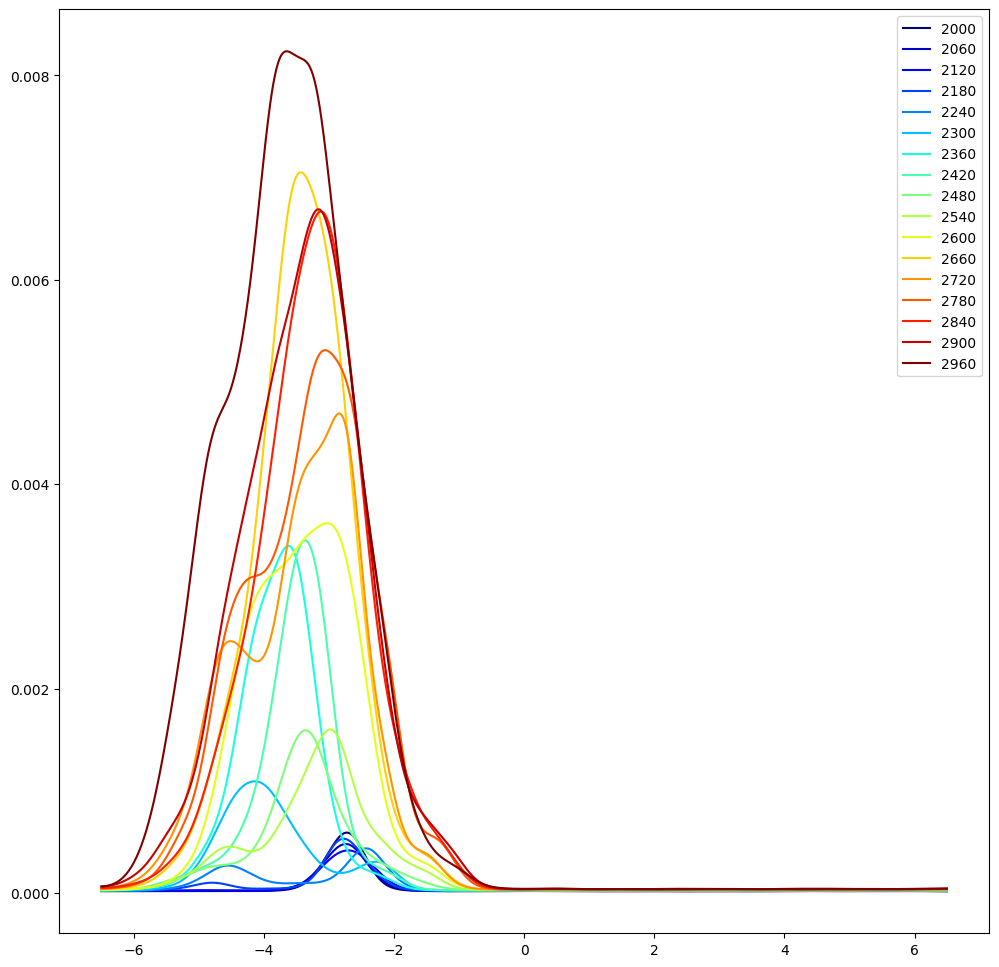

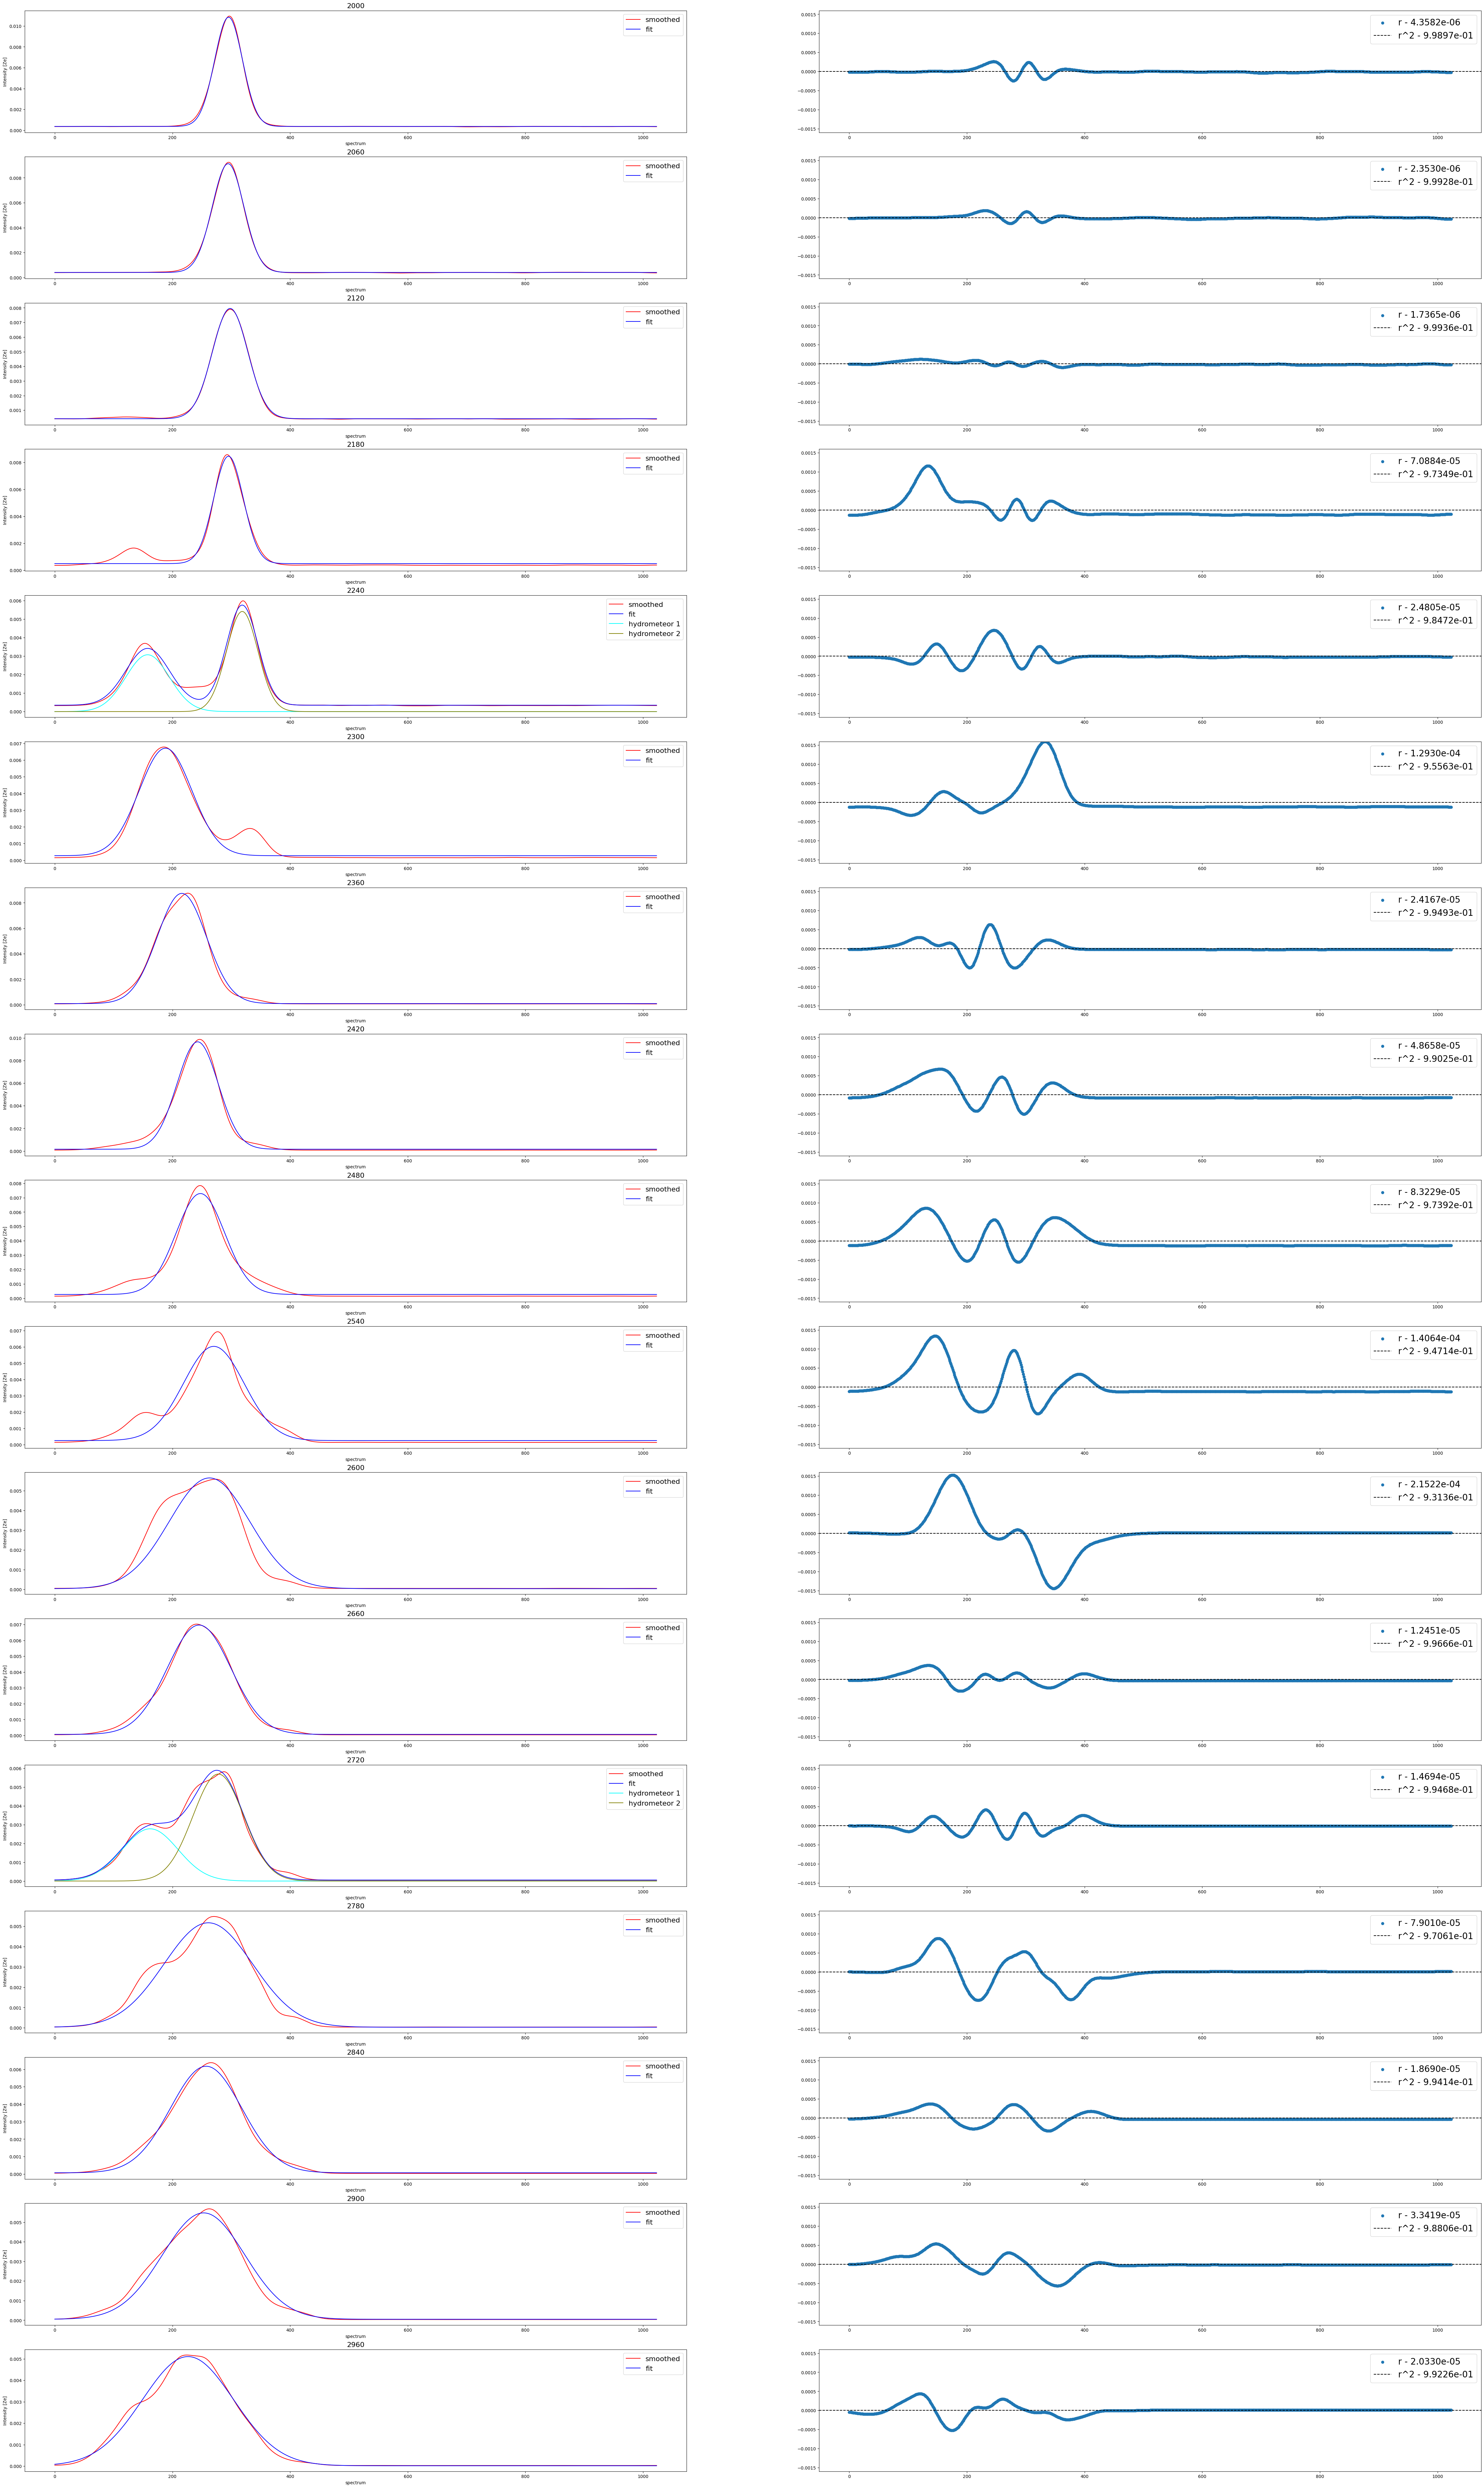

/tmp/ipykernel_3894688/1479252791.py:438: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Set1')


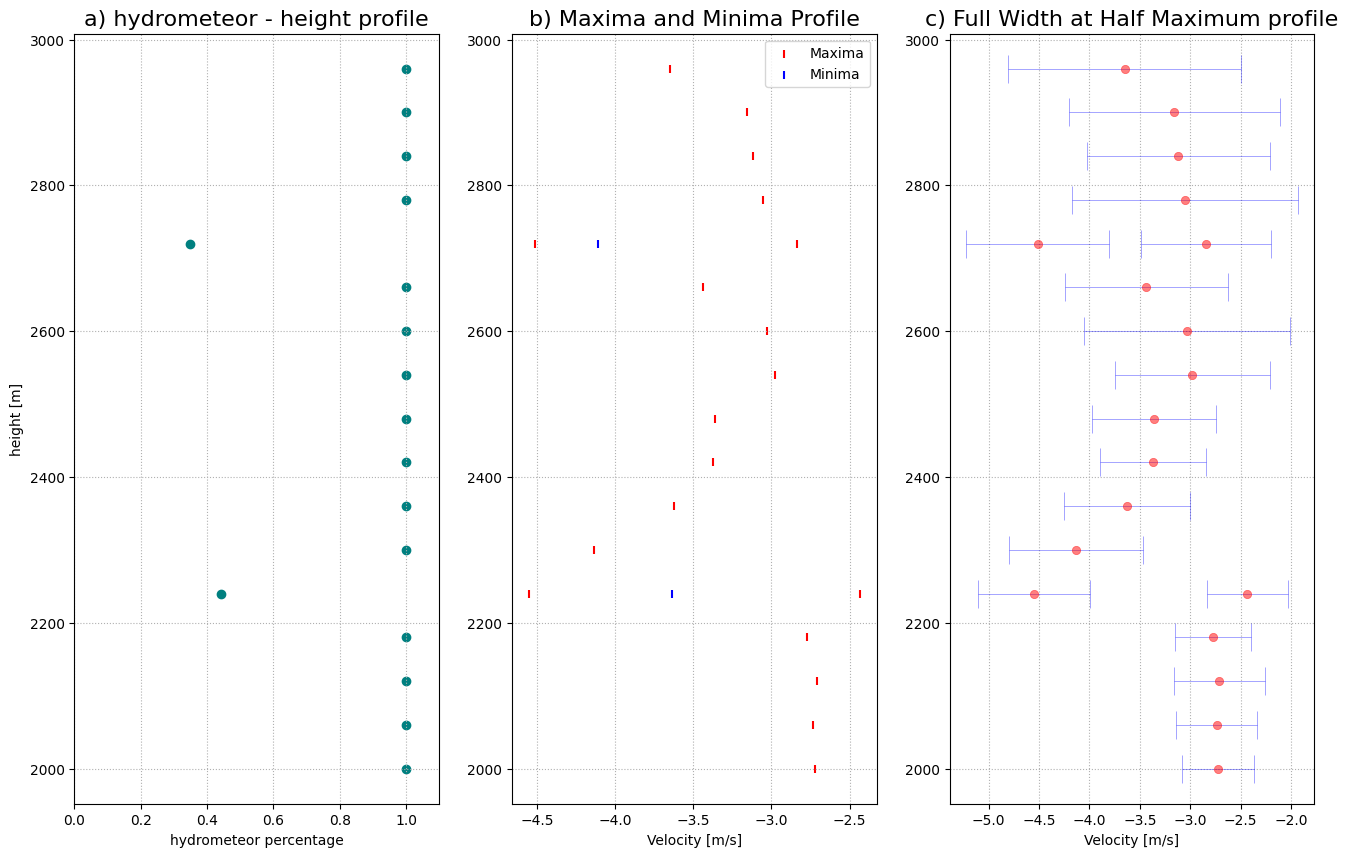

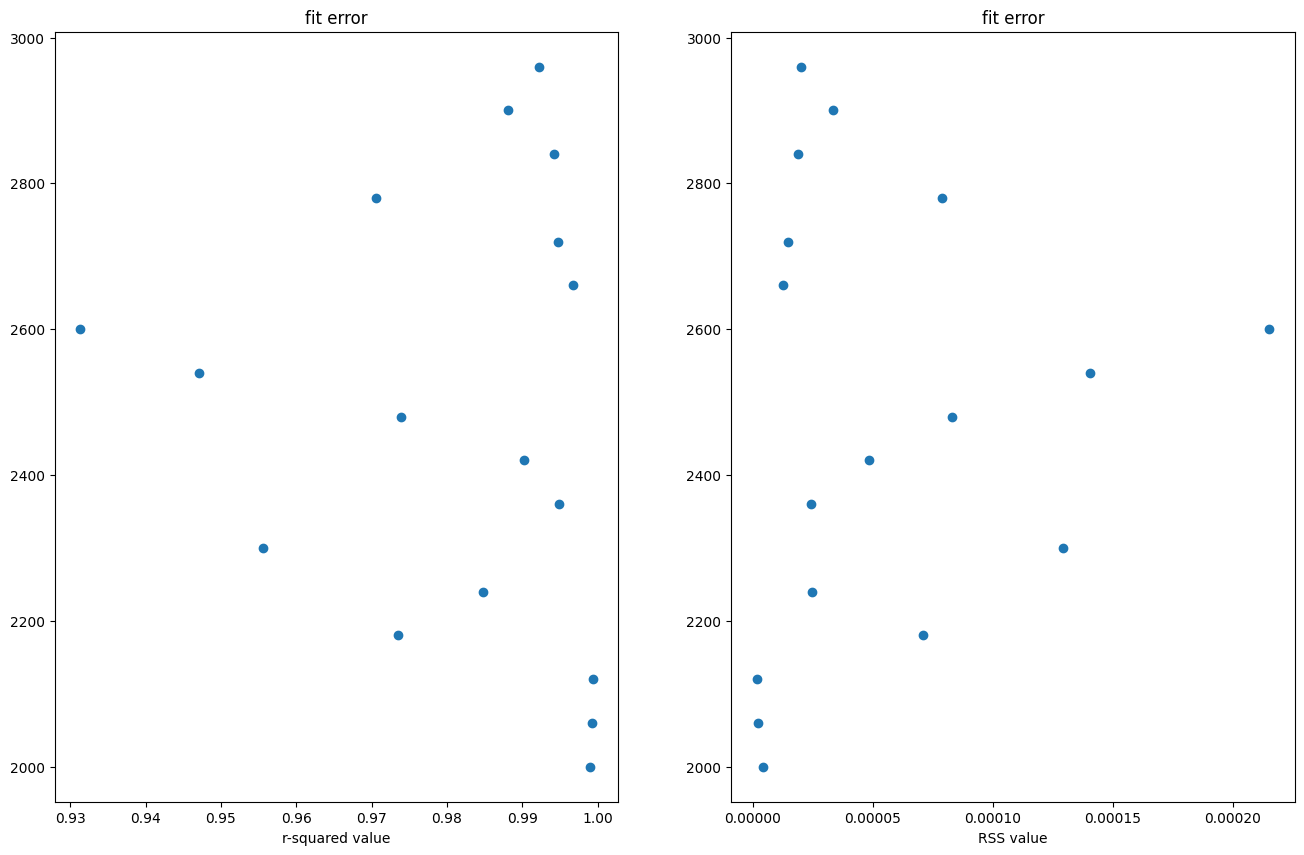

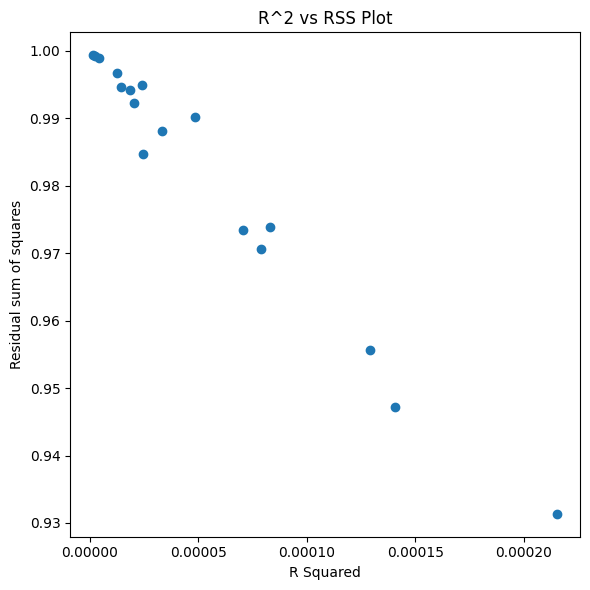

In [55]:
ranges = np.arange(2000, 3000, 60)
time_guess = '20210913T113000.0'
x = weight_finding_algorithm(time_guess, radar_210913_raw, radar_210913_classification, ranges)
weight_finding_results(radar_210913_raw, *x)

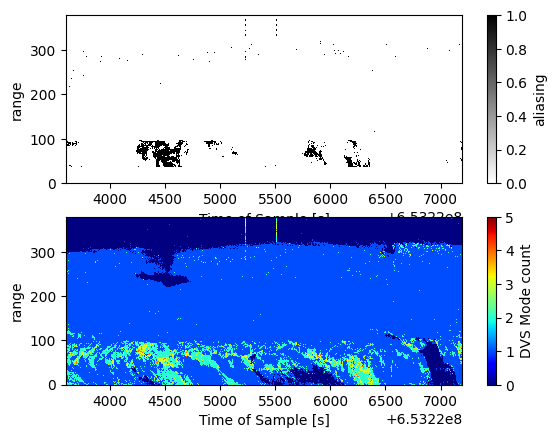

In [56]:
fig, axes = plt.subplots(2)
radar_210913_raw['aliasing'].plot(y='range', cmap = 'binary', ax = axes[0])
radar_210913_raw['mode_number'].plot(y='range', cmap = 'jet', ax = axes[1])

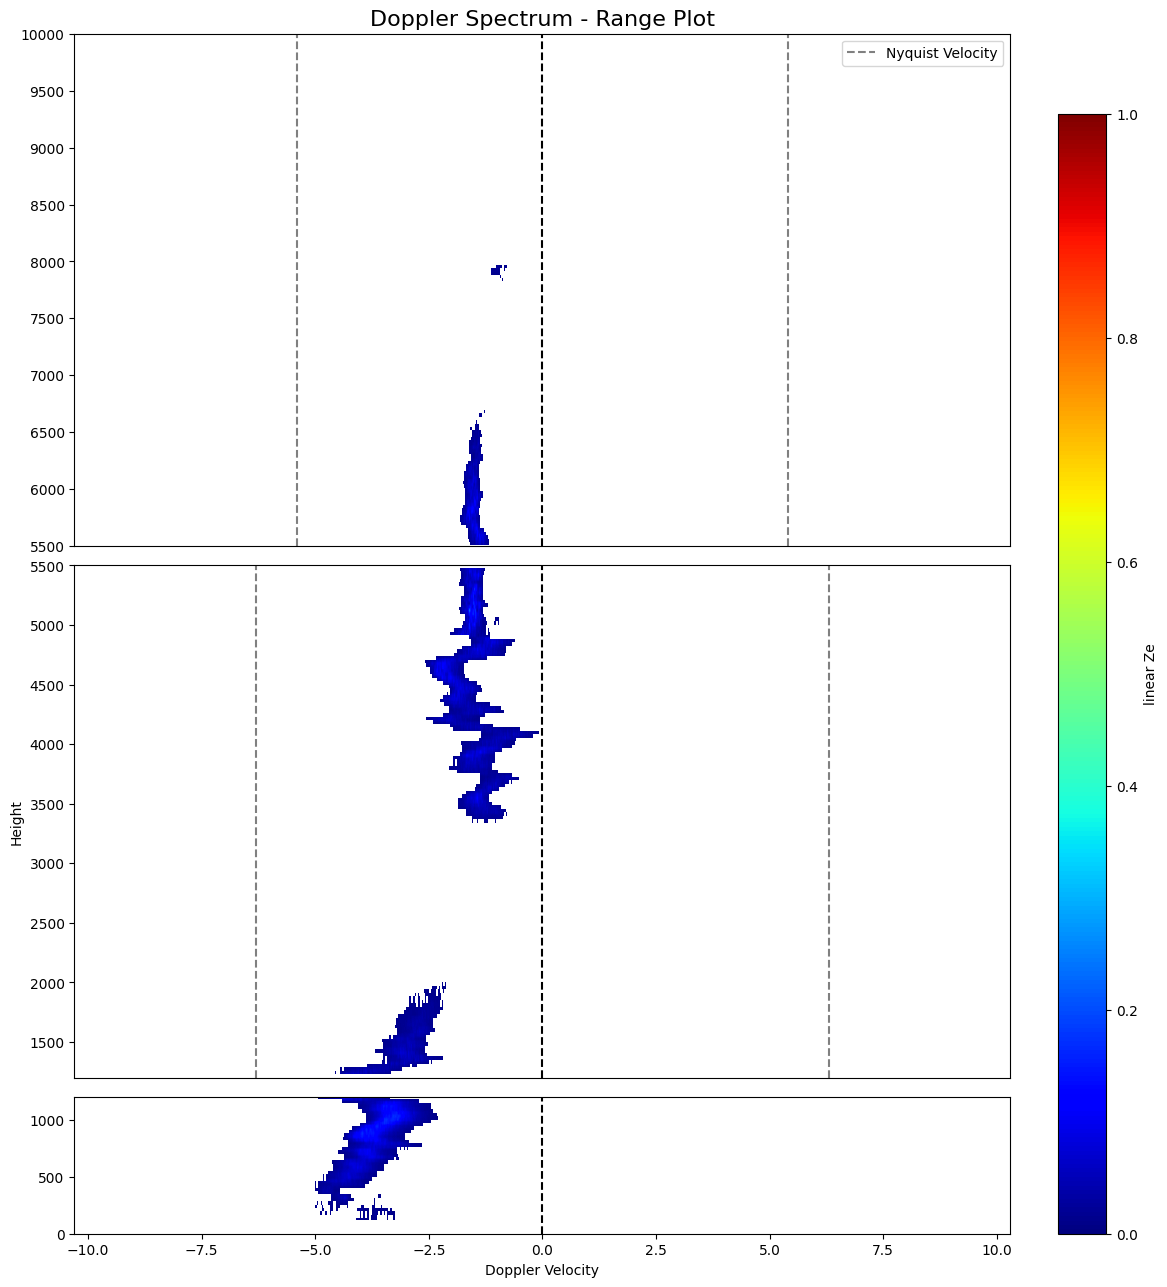

In [57]:
time_guess = '20210913T112000.0'
make_Range_Wavelength_Plot(radar_210913_raw, time_guess)

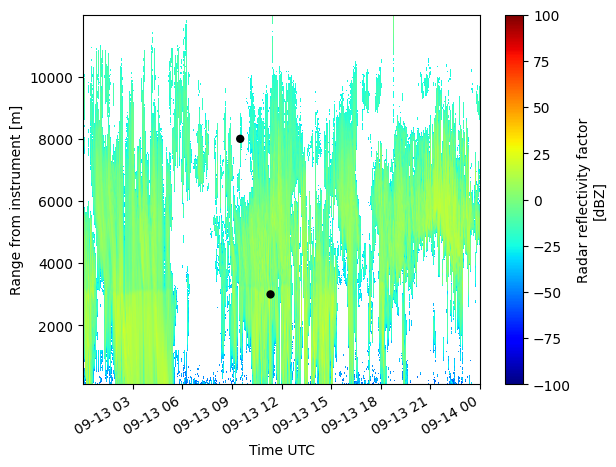

In [58]:
points = [('20210913T112000.0', 3000), ('20210913T093000.0', 8000)]
fig, ax1 = plt.subplots()
plotBackground(
    radar_210913,
    ax1,
    "Zh",
    points = points)

(array([-100.03469 , -100.030914, -100.02335 , ..., -101.39873 ,
        -101.40402 , -101.40668 ], dtype=float32),
 -100.70575,
 -96.70867)

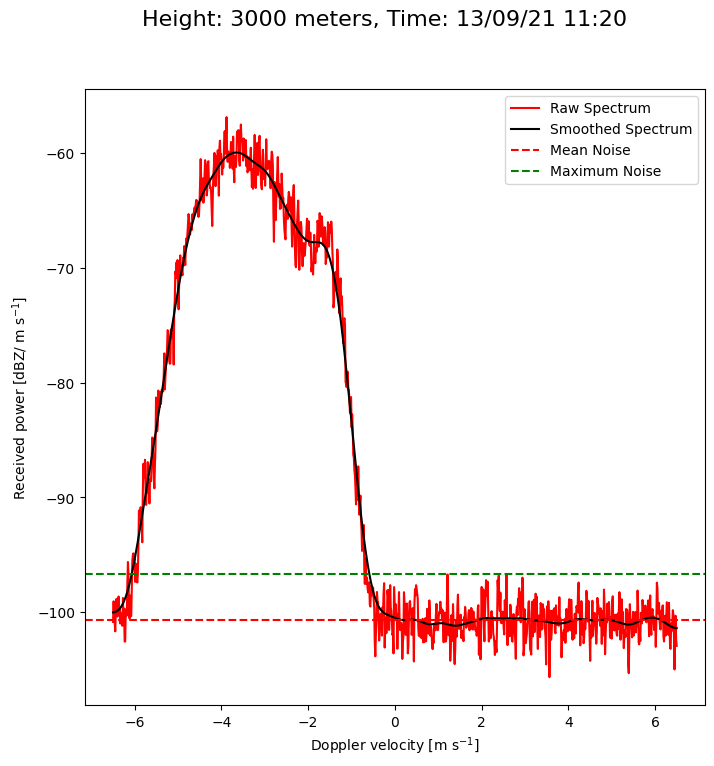

In [59]:
plotFullDopSpec(
    radar_210913_raw,
    '20210913T112000.0',
    3000,
    peak_start = -6.2,
    peak_end = 2,
    show_raw = True,
    show_smoothed = True,
    show_mean_noise = True,
    show_max_noise = True
)